In [14]:
# ===== Cell 1: Setup =====

!pip install -q kagglehub

import kagglehub
import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATA_ROOT = "data"
os.makedirs(DATA_ROOT, exist_ok=True)

print("Setup complete. DATA_ROOT =", DATA_ROOT)

Setup complete. DATA_ROOT = data


In [15]:
# ===== Cell 2: Download datasets via kagglehub =====

# 1) Skin cancer malignant vs benign
path_skin_simple = kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")
print("Downloaded fanconic skin cancer dataset to:", path_skin_simple)

# 2) Chest X-ray pneumonia
path_chest = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Downloaded chest xray dataset to:", path_chest)

# 3) HAM10000
path_ham = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Downloaded HAM10000 dataset to:", path_ham)

Using Colab cache for faster access to the 'skin-cancer-malignant-vs-benign' dataset.
Downloaded fanconic skin cancer dataset to: /kaggle/input/skin-cancer-malignant-vs-benign
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Downloaded chest xray dataset to: /kaggle/input/chest-xray-pneumonia
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Downloaded HAM10000 dataset to: /kaggle/input/skin-cancer-mnist-ham10000


In [16]:
# ===== Organize SkinCancer (fanconic) =====

import os
import shutil

skin_root = path_skin_simple  # from kagglehub.dataset_download("fanconic/skin-cancer-malignant-vs-benign")
print("SkinCancer kagglehub path:", skin_root)
print("Contents:", os.listdir(skin_root))

# On Kaggle, structure is typically:
# skin_root/
#   train/
#       benign/
#       malignant/
#   test/
#       benign/
#       malignant/

src_splits = ["train", "test"]
dest_root = os.path.join(DATA_ROOT, "SkinCancer")
os.makedirs(dest_root, exist_ok=True)

for split in src_splits:
    split_dir = os.path.join(skin_root, split)
    if not os.path.exists(split_dir):
        continue

    for cls in os.listdir(split_dir):
        cls_src = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_src):
            continue

        cls_dst = os.path.join(dest_root, cls)
        os.makedirs(cls_dst, exist_ok=True)

        for fname in os.listdir(cls_src):
            src_path = os.path.join(cls_src, fname)
            dst_path = os.path.join(cls_dst, fname)
            if os.path.isfile(src_path):
                shutil.copy(src_path, dst_path)

print("SkinCancer organized into:", dest_root)
print("Class folders:", os.listdir(dest_root))

SkinCancer kagglehub path: /kaggle/input/skin-cancer-malignant-vs-benign
Contents: ['data', 'test', 'train']
SkinCancer organized into: data/SkinCancer
Class folders: ['benign', 'malignant']


In [17]:
# ===== Cell 3: Copy ZIP files from kagglehub cache to data/ and unzip =====

def copy_zip_and_unzip(source_dir, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)

    for fname in os.listdir(source_dir):
        if fname.endswith(".zip"):
            src = os.path.join(source_dir, fname)
            dst = os.path.join(dest_dir, fname)
            shutil.copy(src, dst)
            !unzip -q "{dst}" -d "{dest_dir}"

# 1) fanconic SkinCancer
copy_zip_and_unzip(path_skin_simple, f"{DATA_ROOT}/SkinCancer")

# 2) Chest X-ray
copy_zip_and_unzip(path_chest, f"{DATA_ROOT}/ChestXray")

# 3) DO NOT unzip HAM10000, KaggleHub already unpacks images
print("Zip extraction complete (HAM10000 already organized by KaggleHub).")


Zip extraction complete (HAM10000 already organized by KaggleHub).


In [18]:
# ===== Cell 4: Organize HAM10000 into data/HAM10000/<class> =====

import os
import shutil
import pandas as pd

# Root where we want the final dataset to live
root = f"{DATA_ROOT}/HAM10000"
os.makedirs(root, exist_ok=True)

# path_ham comes from kagglehub download cell:
# path_ham = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("HAM10000 kagglehub path:", path_ham)
print("Files in kagglehub HAM10000 path:", os.listdir(path_ham))

# 1) Read metadata from kagglehub path
metadata_path = os.path.join(path_ham, "HAM10000_metadata.csv")
df = pd.read_csv(metadata_path)

# 2) Create class folders in data/HAM10000
classes = df["dx"].unique()
for c in classes:
    os.makedirs(os.path.join(root, c), exist_ok=True)

# 3) Directories where images currently live (under kagglehub cache)
image_dirs = [
    os.path.join(path_ham, "HAM10000_images_part_1"),
    os.path.join(path_ham, "HAM10000_images_part_2"),
]

print("Image dirs to search:", image_dirs)

moved, missing = 0, 0

# 4) Copy each image into the correct class folder in data/HAM10000
for img_id, dx in zip(df["image_id"], df["dx"]):
    fname = img_id + ".jpg"
    found = False

    for d in image_dirs:
        src = os.path.join(d, fname)
        if os.path.exists(src):
            dst = os.path.join(root, dx, fname)
            shutil.copy(src, dst)   # use copy to keep kagglehub cache intact
            moved += 1
            found = True
            break

    if not found:
        missing += 1

print(f"HAM10000 organized into {root}")
print("Images copied:", moved, "| Missing:", missing)


HAM10000 kagglehub path: /kaggle/input/skin-cancer-mnist-ham10000
Files in kagglehub HAM10000 path: ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']
Image dirs to search: ['/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1', '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2']
HAM10000 organized into data/HAM10000
Images copied: 10015 | Missing: 0


In [19]:
#check ^
import glob

print("\n=== HAM10000 ===")
for cls in os.listdir("data/HAM10000"):
    p = os.path.join("data/HAM10000", cls)
    if os.path.isdir(p):
        print(cls, "->", len(glob.glob(os.path.join(p, "*.jpg"))), "images")



=== HAM10000 ===
df -> 115 images
mel -> 1113 images
nv -> 6705 images
bkl -> 1099 images
akiec -> 327 images
vasc -> 142 images
bcc -> 514 images


In [20]:
# ===== Cell 5: Organize ChestXray from kagglehub path =====

import os
import shutil

# path_chest must come from Cell 2:
# path_chest = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("ChestXray kagglehub path:", path_chest)
print("Contents at path_chest:", os.listdir(path_chest))

# KaggleHub structure is usually:
# path_chest/
#   chest_xray/
#       train/
#       val/
#       test/
# or sometimes it contains files directly.
# Detect the correct root.
src_root = path_chest
if "chest_xray" in os.listdir(path_chest):
    src_root = os.path.join(path_chest, "chest_xray")

print("Using src_root:", src_root)

dest_root = os.path.join(DATA_ROOT, "ChestXray")
os.makedirs(dest_root, exist_ok=True)

# Final folder structure:
# data/ChestXray/
#    NORMAL/
#    PNEUMONIA/
for cls in ["NORMAL", "PNEUMONIA"]:
    os.makedirs(os.path.join(dest_root, cls), exist_ok=True)

splits = ["train", "test", "val"]

copied = 0
for split in splits:
    split_dir = os.path.join(src_root, split)
    if not os.path.exists(split_dir):
        continue

    for cls in ["NORMAL", "PNEUMONIA"]:
        src_dir = os.path.join(split_dir, cls)
        if not os.path.exists(src_dir):
            continue

        dst_dir = os.path.join(dest_root, cls)
        for fname in os.listdir(src_dir):
            src_path = os.path.join(src_dir, fname)
            dst_path = os.path.join(dst_dir, fname)
            if os.path.isfile(src_path):
                shutil.copy(src_path, dst_path)
                copied += 1

print(f"\nChestXray organized into {dest_root}")
print("Total images copied:", copied)
print("Final ChestXray folders:", os.listdir(dest_root))


ChestXray kagglehub path: /kaggle/input/chest-xray-pneumonia
Contents at path_chest: ['chest_xray']
Using src_root: /kaggle/input/chest-xray-pneumonia/chest_xray

ChestXray organized into data/ChestXray
Total images copied: 5856
Final ChestXray folders: ['PNEUMONIA', 'NORMAL']


In [21]:
#check ^
import glob, os

print("=== ChestXray image counts ===")
for cls in ["NORMAL", "PNEUMONIA"]:
    class_dir = os.path.join("data/ChestXray", cls)
    num_imgs = len(glob.glob(os.path.join(class_dir, "*.jpeg"))) \
             + len(glob.glob(os.path.join(class_dir, "*.jpg"))) \
             + len(glob.glob(os.path.join(class_dir, "*.png")))
    print(cls, "->", num_imgs, "images")

=== ChestXray image counts ===
NORMAL -> 1583 images
PNEUMONIA -> 4273 images


In [22]:
# ===== Cell 6: Verify =====

for folder in ["HAM10000", "SkinCancer", "ChestXray"]:
    print("\n===", folder, "===")
    print(os.listdir(f"{DATA_ROOT}/{folder}")[:10])



=== HAM10000 ===
['df', 'mel', 'nv', 'bkl', 'akiec', 'vasc', 'bcc']

=== SkinCancer ===
['benign', 'malignant']

=== ChestXray ===
['PNEUMONIA', 'NORMAL']



Dataset: HAM10000
Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Batch shape: (32, 224, 224, 3) (32, 7)


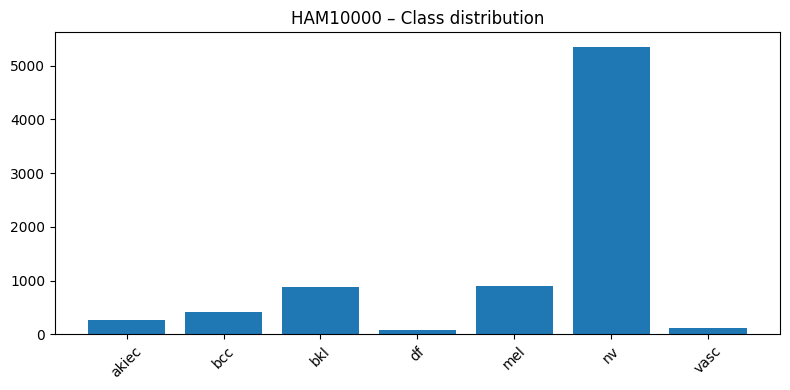

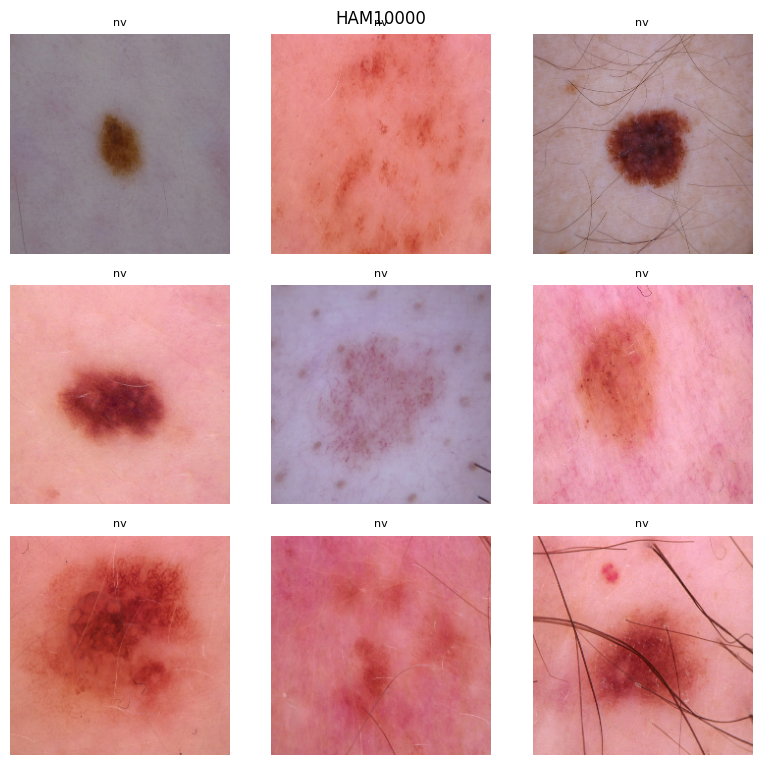


Dataset: SkinCancer
Found 3297 files belonging to 2 classes.
Using 2638 files for training.
Found 3297 files belonging to 2 classes.
Using 659 files for validation.
Classes: ['benign', 'malignant']
Batch shape: (32, 224, 224, 3) (32, 2)


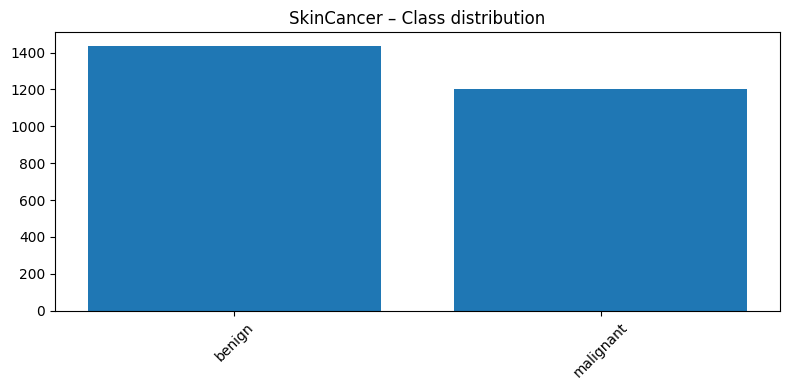

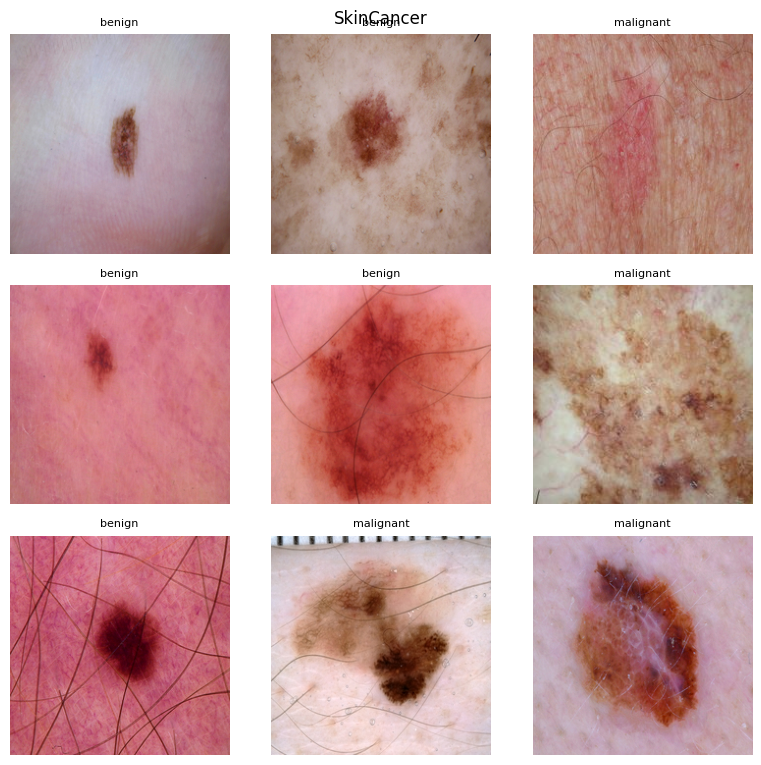


Dataset: ChestXray
Found 5856 files belonging to 2 classes.
Using 4685 files for training.
Found 5856 files belonging to 2 classes.
Using 1171 files for validation.
Classes: ['NORMAL', 'PNEUMONIA']
Batch shape: (32, 224, 224, 3) (32, 2)


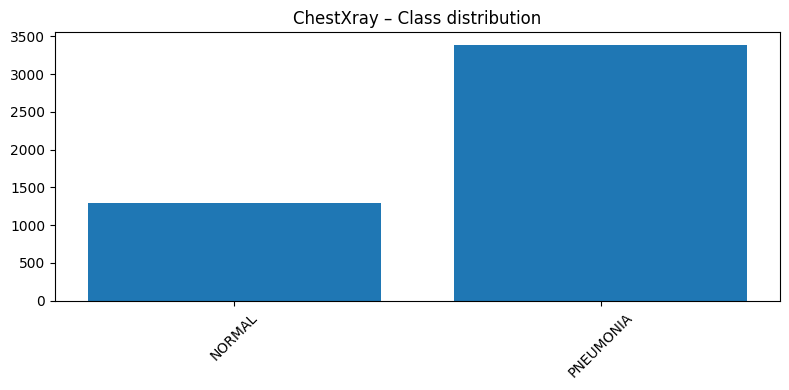

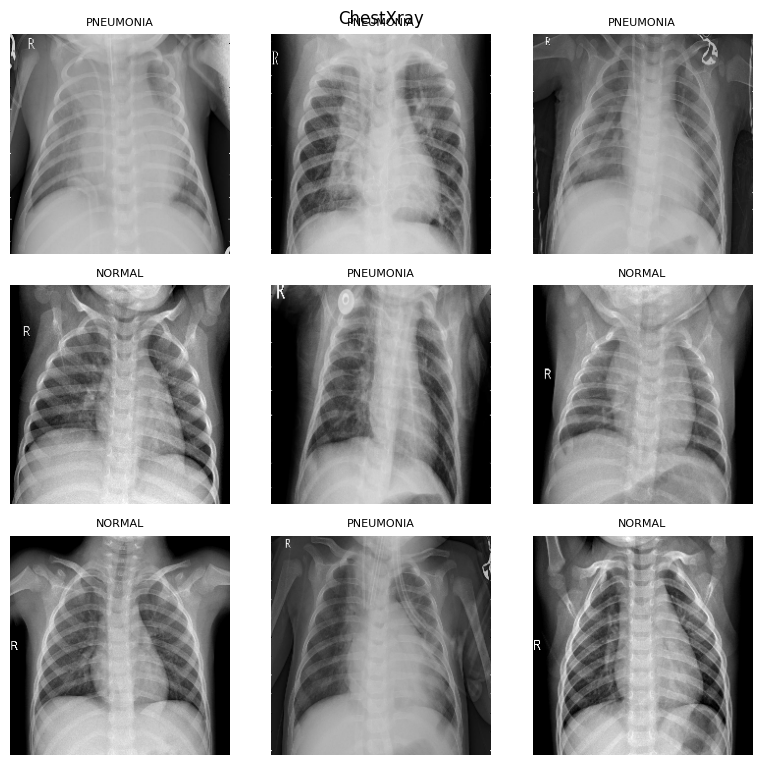

In [23]:
# ===== Cell 7: EDA on all three datasets =====

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os

DATASET_NAMES = ["HAM10000", "SkinCancer", "ChestXray"]
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

def get_datasets(dataset_name, validation_split=0.2):
    dataset_dir = os.path.join(DATA_ROOT, dataset_name)
    train_ds = keras.utils.image_dataset_from_directory(
        dataset_dir,
        labels="inferred",
        label_mode="categorical",
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
        validation_split=validation_split,
        subset="training",
    )
    val_ds = keras.utils.image_dataset_from_directory(
        dataset_dir,
        labels="inferred",
        label_mode="categorical",
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
        validation_split=validation_split,
        subset="validation",
    )
    class_names = train_ds.class_names
    num_classes = len(class_names)
    AUTOTUNE = tf.data.AUTOTUNE
    return (train_ds.cache().prefetch(AUTOTUNE),
            val_ds.cache().prefetch(AUTOTUNE),
            class_names,
            num_classes)


def plot_class_distribution(train_ds, class_names, title=""):
    counts = np.zeros(len(class_names), dtype=int)
    for _, labels in train_ds:
        ids = np.argmax(labels.numpy(), axis=1)
        for x in ids:
            counts[x] += 1

    plt.figure(figsize=(8,4))
    plt.bar(class_names, counts)
    plt.xticks(rotation=45)
    plt.title(title + " – Class distribution")
    plt.tight_layout()
    plt.show()


def show_sample_images(train_ds, class_names, n=9, title=""):
    plt.figure(figsize=(8,8))
    for images, labels in train_ds.take(1):
        for i in range(min(n, len(images))):
            ax = plt.subplot(3,3,i+1)
            plt.imshow(images[i].numpy().astype('uint8'))
            plt.title(class_names[np.argmax(labels[i])], fontsize=8)
            plt.axis("off")
    plt.suptitle(title, y=0.95)
    plt.tight_layout()
    plt.show()


for ds in DATASET_NAMES:
    print("\n" + "="*60)
    print("Dataset:", ds)
    print("="*60)

    train_ds, val_ds, class_names, num_classes = get_datasets(ds)
    print("Classes:", class_names)

    # Check shapes
    for images, labels in train_ds.take(1):
        print("Batch shape:", images.shape, labels.shape)
        break

    # Plot
    plot_class_distribution(train_ds, class_names, title=ds)
    show_sample_images(train_ds, class_names, title=ds)

In [24]:
# ===== Cell 8: Preprocessing (augmentation + normalization) =====
from keras import layers

AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)

normalization = layers.Rescaling(1.0 / 255.0, name="rescale_0_1")


def preprocess_train(image, label, augment=True):
    if augment:
        image = data_augmentation(image)
    image = normalization(image)
    return image, label


def preprocess_val(image, label):
    image = normalization(image)
    return image, label


def get_preprocessed_datasets(dataset_name, validation_split=0.2, augment=True):
    raw_train_ds, raw_val_ds, class_names, num_classes = get_datasets(
        dataset_name, validation_split=validation_split
    )

    train_ds = raw_train_ds.map(
        lambda x, y: preprocess_train(x, y, augment=augment),
        num_parallel_calls=AUTOTUNE,
    )

    val_ds = raw_val_ds.map(
        preprocess_val,
        num_parallel_calls=AUTOTUNE,
    )

    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)

    return train_ds, val_ds, class_names, num_classes

In [25]:
# ===== Cell 9: get preprocessed datasets =====

ham_train, ham_val, ham_classes, ham_n = get_preprocessed_datasets("HAM10000")
skin_train, skin_val, skin_classes, skin_n = get_preprocessed_datasets("SkinCancer")
cx_train,  cx_val,  cx_classes,  cx_n  = get_preprocessed_datasets("ChestXray")

print("HAM10000 classes:", ham_classes)
print("SkinCancer classes:", skin_classes)
print("ChestXray classes:", cx_classes)

Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Found 3297 files belonging to 2 classes.
Using 2638 files for training.
Found 3297 files belonging to 2 classes.
Using 659 files for validation.
Found 5856 files belonging to 2 classes.
Using 4685 files for training.
Found 5856 files belonging to 2 classes.
Using 1171 files for validation.
HAM10000 classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
SkinCancer classes: ['benign', 'malignant']
ChestXray classes: ['NORMAL', 'PNEUMONIA']


In [26]:
# ===== Cell 10: Baseline CNN skeleton (will refine) =====

def build_baseline_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="baseline_cnn")
    return model


def compile_and_train(model, train_ds, val_ds, epochs=10, lr=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
    )
    return history

# Example: train on SkinCancer binary dataset
input_shape = IMAGE_SIZE + (3,)
model_skin = build_baseline_cnn(input_shape, skin_n)
history_skin = compile_and_train(model_skin, skin_train, skin_val, epochs=5)

Epoch 1/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 309s 4s/step - accuracy: 0.6092 - loss: 0.6656 - val_accuracy: 0.7891 - val_loss: 0.4828
Epoch 2/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 299s 4s/step - accuracy: 0.7286 - loss: 0.5104 - val_accuracy: 0.7921 - val_loss: 0.4407
Epoch 3/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 292s 3s/step - accuracy: 0.7394 - loss: 0.4806 - val_accuracy: 0.7997 - val_loss: 0.4261
Epoch 4/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 305s 4s/step - accuracy: 0.7572 - loss: 0.4661 - val_accuracy: 0.7951 - val_loss: 0.4085
Epoch 5/5
83/83 ━━━━━━━━━━━━━━━━━━━━ 299s 4s/step - accuracy: 0.7671 - loss: 0.4530 - val_accuracy: 0.7951 - val_loss: 0.3992
